In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
pd.options.display.float_format = '{:_.2f}'.format
files = ["metrics/lr_metrics.pkl", "metrics/rf_metrics.pkl", 
         "metrics/xgb_metrics.pkl", "metrics/knn_metrics.pkl", 
         "metrics/tree_metrics.pkl","metrics/lr_log_metrics.pkl", 
         "metrics/rf_log_metrics.pkl", "metrics/xgb_log_metrics.pkl", 
         "metrics/knn_log_metrics.pkl", "metrics/tree_log_metrics.pkl"
]

all_metrics = []

for file in files:
    with open(file, "rb") as f:
        all_metrics.append(pickle.load(f))

df = pd.DataFrame(all_metrics)
df['Target'] = ['price']*5 + ['log_price']*5
df = df[['model_name', 'Target', 'MAE', 'RMSE', 'MSE', 'R2']]
df = df.sort_values(by=['model_name','Target']).reset_index(drop=True)
df

,model_name,Target,MAE,RMSE,MSE,R2
0,Decision Tree,price,224_382.39,376_158.60,141_495_288_840.40,0.86
1,Decision Tree Log,log_price,225_555.82,380_689.37,144_924_397_206.23,0.86
2,KNearestNeighbors,price,499_583.75,872_324.49,760_950_018_739.53,0.27
3,KNearestNeighbors Log,log_price,538_566.21,933_845.59,872_067_577_121.76,0.17
4,Linear Regression,price,328_809.37,630_816.75,397_929_774_235.88,0.62
5,Linear Regression Log,log_price,246_513.75,440_297.20,193_861_623_301.85,0.81
6,Random Forest,price,190_047.58,310_360.81,96_323_832_172.77,0.91
7,Random Forest Log,log_price,197_389.88,321_778.27,103_541_256_750.19,0.90
8,XGBoost,price,184_784.39,296_345.78,87_820_820_520.27,0.92
9,XGBoost Log,log_price,193_512.39,315_251.63,99_383_589_560.28,0.90


In [3]:
sns.set(style="whitegrid")

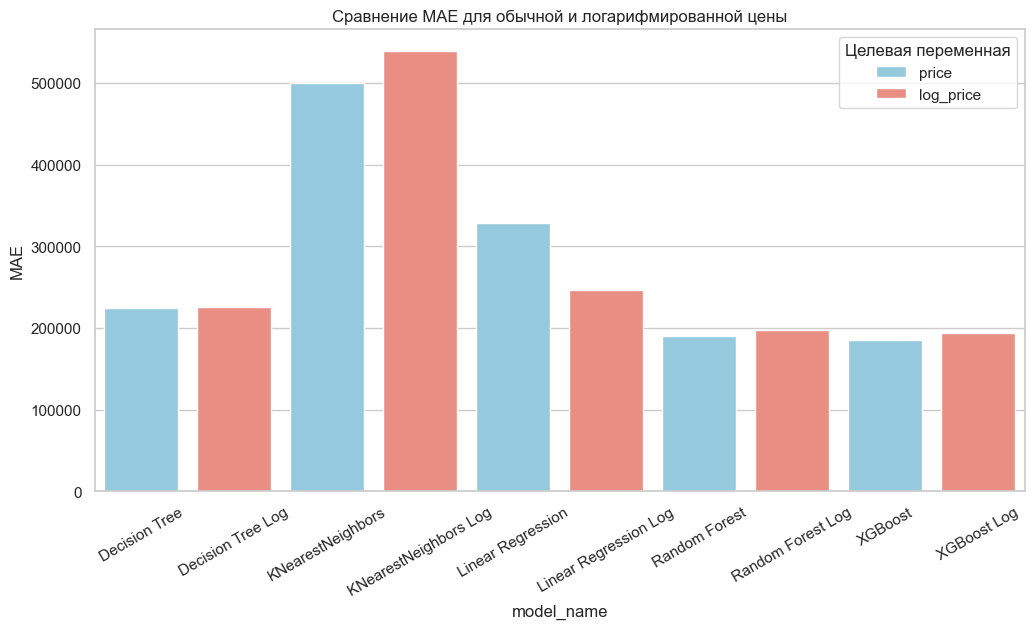

In [4]:
plt.figure(figsize=(12,6))
sns.barplot(x="model_name", y="MAE", hue="Target", data=df, palette=["skyblue","salmon"])
plt.title("Сравнение MAE для обычной и логарифмированной цены")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.legend(title="Целевая переменная")
plt.show()

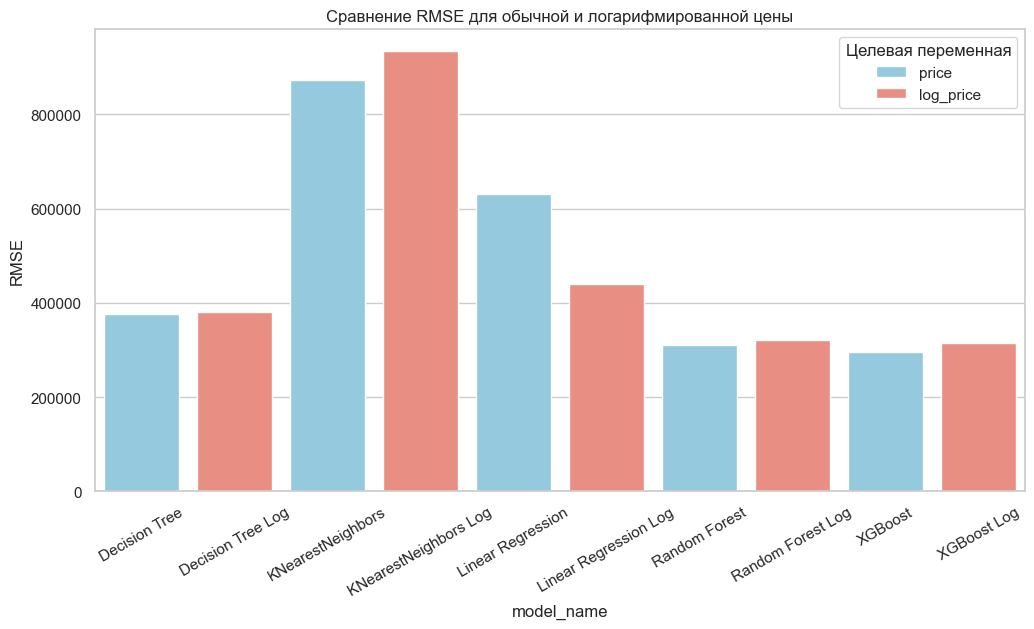

In [5]:
plt.figure(figsize=(12,6))
sns.barplot(x="model_name", y="RMSE", hue="Target", data=df, palette=["skyblue","salmon"])
plt.title("Сравнение RMSE для обычной и логарифмированной цены")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.legend(title="Целевая переменная")
plt.show()

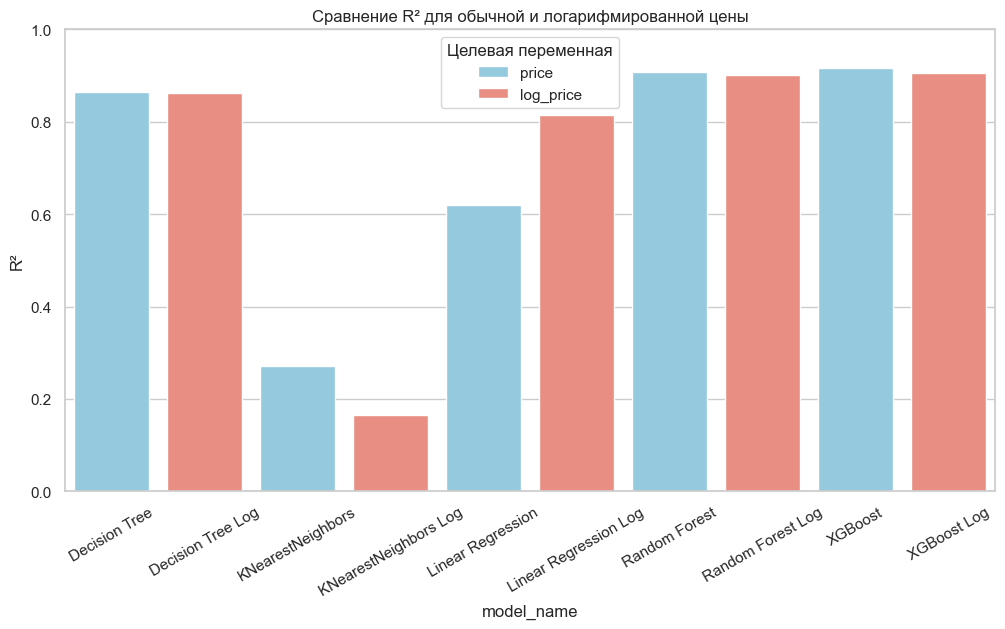

In [6]:
plt.figure(figsize=(12,6))
sns.barplot(x="model_name", y="R2", hue="Target", data=df, palette=["skyblue","salmon"])
plt.title("Сравнение R² для обычной и логарифмированной цены")
plt.ylabel("R²")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(title="Целевая переменная")
plt.show()

In [7]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025.csv')
np.mean(df['Цена'])

np.float64(693803.683426)